In [1]:
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_RNA.h5ad
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_protein.h5ad
!pip install pyro-ppl graphviz seaborn anndata

File ‘PapalexiSatija2021_eccite_RNA.h5ad’ already there; not retrieving.

File ‘PapalexiSatija2021_eccite_protein.h5ad’ already there; not retrieving.


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import multiprocessing

multiprocessing.cpu_count()

10

In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import (
    SVI,
    TraceEnum_ELBO,
    Trace_ELBO,
    TraceMeanField_ELBO,
    JitTraceEnum_ELBO,
    config_enumerate,
    infer_discrete,
)

from torch.utils.data import (
    Dataset,
    Sampler,
    DataLoader,
    WeightedRandomSampler,
    SubsetRandomSampler,
    BatchSampler,
)

from pyro.optim import Adam, ClippedAdam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

if torch.cuda.is_available():
    print("Let's ride")
    device = "cuda"
    torch.set_float32_matmul_precision("high")
    # torch.set_default_device("cuda")
    smoke_test = False
else:
    device = "cpu"
    smoke_test = True
smoke_test = True


In [4]:
adata = ad.read("PapalexiSatija2021_eccite_RNA.h5ad")
adata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [5]:
prot_adata = ad.read("PapalexiSatija2021_eccite_protein.h5ad")
prot_adata.var_names = prot_adata.var_names + "_protein"

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [6]:
prot_df = prot_adata.to_df().join(prot_adata.obs)
prot_df


,CD86_protein,PDL1_protein,PDL2_protein,CD366_protein,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,...,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,118.0,522.0,94.0,67.0,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,801.0,0.0,0.0
AAACCTGAGTGGACGT,243.0,139.0,104.0,59.0,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,545.0,0.0,0.0
AAACCTGCATGAGCGA,99.0,109.0,56.0,80.0,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,344.0,0.0,0.0
AAACCTGTCTTGTCAT,110.0,334.0,48.0,47.0,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,539.0,0.0,0.0
AAACGGGAGAACAACT,303.0,593.0,77.0,80.0,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,1053.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,98.0,151.0,135.0,14.0,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,398.0,0.0,0.0
TTTGTCAGTGACGGTA,1781.0,1117.0,89.0,55.0,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,0,4,3042.0,0.0,0.0
TTTGTCAGTTCCACAA,84.0,73.0,38.0,17.0,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,212.0,0.0,0.0
TTTGTCATCACGCATA,18.0,135.0,37.0,68.0,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,258.0,0.0,0.0


In [7]:
# adata = ad.concat((prot_adata, adata), axis=1, merge="first")
# adata

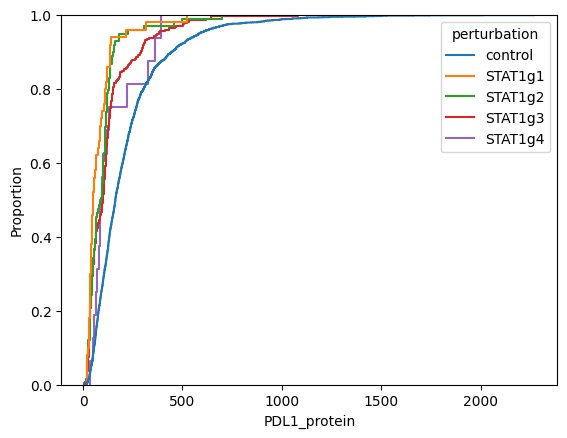

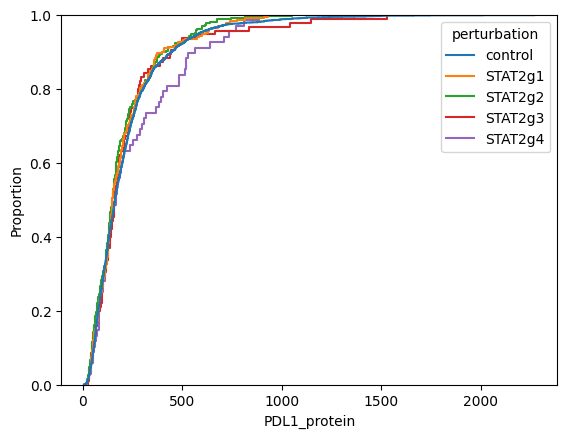

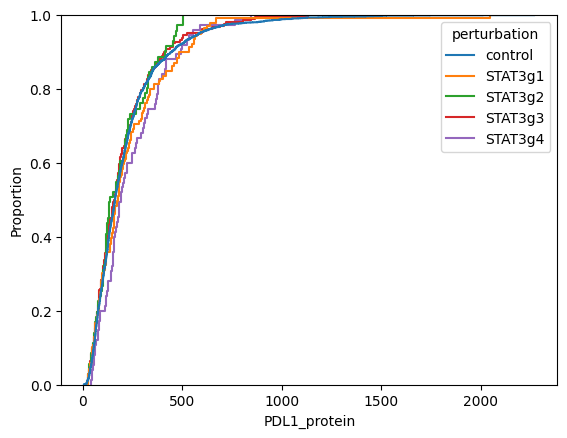

In [8]:
plot_gene = "STAT1"
for plot_gene in ["STAT1", "STAT2", "STAT3"]:
    sns.ecdfplot(prot_df, hue="perturbation", x="PDL1_protein", hue_order=["control"]+[f"{plot_gene}g{i}" for i in range(1,5)])
    plt.show()

In [9]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578


In [10]:
n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
n_ribo = n_rps + n_rpl
n_total = adata.X.sum(axis=1).A1
# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)

In [11]:
adata.obs = adata.obs.assign(
    element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True)
)
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [12]:
# pick a subset of random genes including 3 known ones
# stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones

if smoke_test:
    n_genes_subset = 50
    target_genes = [e for e in adata.obs["element"].unique() if e != "control"]
    # target_genes += prot_adata.var_names.tolist()
    other_genes = [gene for gene in adata.var_names if gene not in target_genes]
    selected_genes = target_genes + other_genes[: n_genes_subset - len(target_genes)]
    # selected_genes = stat_target_genes + list(
    #     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    # )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    min_counts = 100 # min no. of cells with at least 1 count
    selected_genes = ((adata.X>0).sum(axis=0)) > min_counts
    adata_subset = adata[:, selected_genes]
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 50
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [13]:
adata_subset.var_names

Index(['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', 'ATF2', 'STAT3', 'JAK2',
       'NFKBIA', 'SMAD4', 'STAT5A', 'CMTM6', 'IFNGR1', 'UBE2L6', 'PDCD1LG2',
       'CUL3', 'BRD4', 'MARCH8', 'IRF1', 'POU2F2', 'ETV7', 'IFNGR2',
       'TNFRSF14', 'SPI1', 'MYC', 'AL627309.1', 'AP006222.2', 'RP4-669L17.10',
       'RP11-206L10.3', 'RP11-206L10.2', 'RP11-206L10.9', 'LINC00115',
       'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4', 'ISG15',
       'AGRN', 'RP11-54O7.18', 'C1orf159', 'TNFRSF18', 'TNFRSF4', 'SDF4',
       'B3GALT6', 'FAM132A', 'RP5-902P8.12', 'UBE2J2', 'SCNN1D'],
      dtype='object', name='gene_symbol')

In [14]:
# from siphon.module import train
import mudata as md
grna_observed = pd.get_dummies(adata_subset.obs["guide_id"]).astype(int)

In [15]:
guide_by_element = (
    pd.crosstab(adata_subset.obs["guide_id"], adata_subset.obs["element"])
    .reindex(index=grna_observed.columns)
    > 0
).astype(int)
guide_by_element

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6,control
ATF2g1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRD4g1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
UBE2L6g1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [16]:
n_elements = guide_by_element.shape[1]
gene_by_element = (
    pd.DataFrame(np.eye(n_elements), index=guide_by_element.columns, columns=guide_by_element.columns)
    .reindex(index=adata_subset.var_names)
    .fillna(0)
)
adata_subset.varm["element_targets"] = gene_by_element
adata_subset.varm["element_targets"]

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_30718/1485371578.py:7: ImplicitModificationWarning: Setting element `.varm['element_targets']` of view, initializing view as actual.
  adata_subset.varm["element_targets"] = gene_by_element


element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6,control
gene_symbol,,,,,,,,,,,,,,,,,,,,,
STAT2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
CAV1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
CD86,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IRF7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ATF2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
JAK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NFKBIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
gdata = ad.AnnData(grna_observed, varm={"guide_targets": guide_by_element})
mdata = md.MuData({"rna":adata_subset, "grna":gdata})
mdata

MuData object with n_obs × n_vars = 20729 × 157
  2 modalities
    rna:	20729 x 50
      obs:	'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
      var:	'ensembl_id', 'ncounts', 'ncells'
      varm:	'element_targets'
    grna:	20729 x 107
      varm:	'guide_targets'

In [18]:
mdata["rna"].obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [19]:
import perturbo
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_targets",
    gene_by_element_key="element_targets",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="mixture", n_factors=5, n_pert_factors=10)
model.view_anndata_setup()


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


INFO     Using column names from columns of adata.varm['element_targets']                                          
INFO     Using column names from columns of adata.varm['guide_targets']                                            


<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:101: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

...

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   5   │
│         n_cells         │ 20729 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │  107  │
│   n_targeted_elements   │  26   │
│    n_tested_elements    │  26   │
│         n_vars          │  50   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │       adata.mod['grna'].varm['guide_targets']        │
│    tested_elements    │       adata.mod['rna'].varm['element_targets']       │
└───────────────────────┴──────────────────────────────────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['hto'] │  rep1-tx   │          0          │
│                  │ rep2-ctrl  │          1          │
│                  │  rep2-tx   │          2          │
│                  │  rep3-tx   │          3          │
│                  │  rep4-tx   │          4          │
└──────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

In [20]:
model.train(
    100,
    lr=0.01,
    batch_size=512,
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_min_delta=1e-3,
    early_stopping_monitor="elbo_train",
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 37/100:  36%|███▌      | 36/100 [00:28<00:52,  1.22it/s, v_num=1, elbo_train=1.02e+6]

In [21]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)


AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [22]:
# plt.scatter(siphon_model.dataset.size_factor, siphon_model.guide.median()["size_factor_fit"], alpha=0.01)

In [23]:
# plt.plot(losses)

In [24]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [25]:
guide=model.module.guide
guides = mdata["grna"].var_names
elements = guide_by_element.index
guide.median().keys()

dict_keys(['guide_efficacy', 'pert_factors', 'pert_loadings', 'cell_factors', 'cell_loadings', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

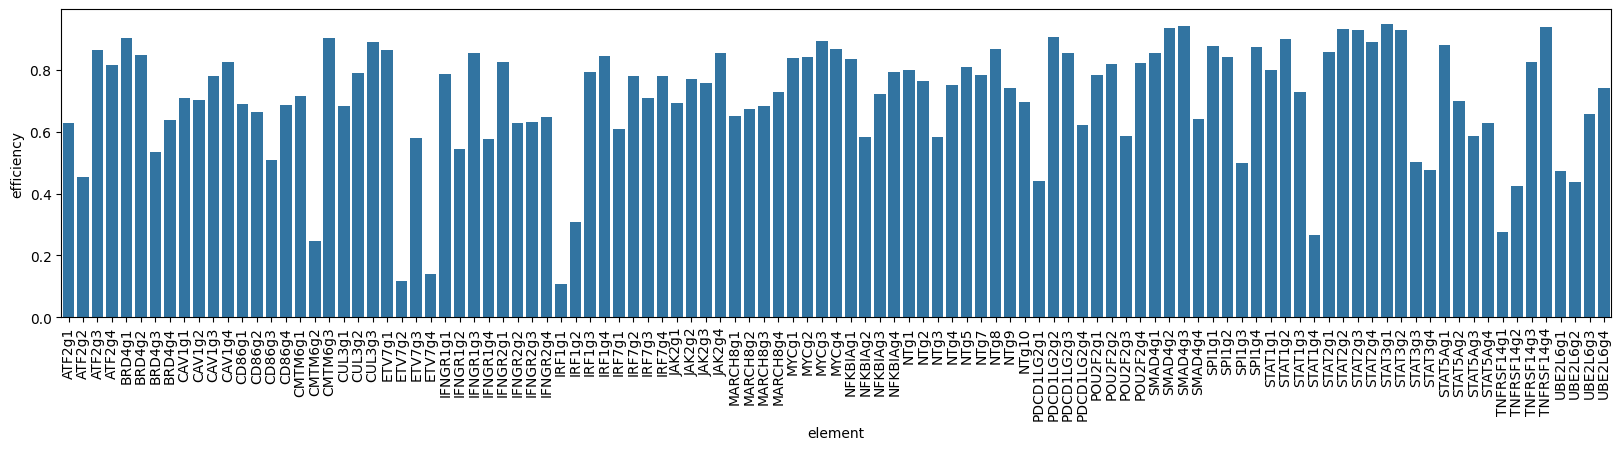

In [26]:
guides = guide_by_element.index
elements = guide_by_element.columns
plt.figure(figsize=(20, 4))
if "guide_efficacy" in guide.median():
    element_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=guides,
        columns=["efficiency"],
    ).reset_index(names="element")
    element_efficiency
    sns.barplot(element_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

array([[<Axes: title={'center': 'efficiency'}>]], dtype=object)

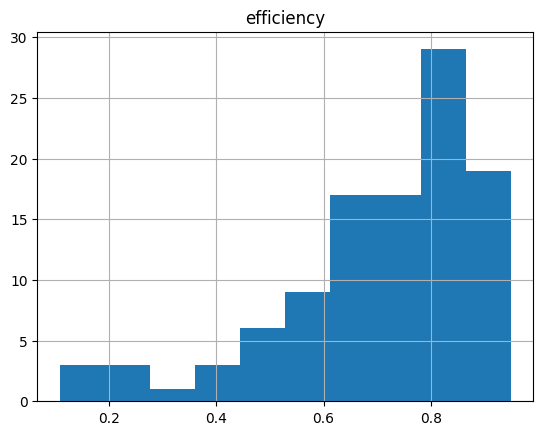

In [27]:
median_efficiency = pd.DataFrame(
    guide.median()["guide_efficacy"].detach().cpu(),
    index=guides,
    columns=["efficiency"],
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'ATF2'),
  Text(1, 0, 'BRD4'),
  Text(2, 0, 'CAV1'),
  Text(3, 0, 'CD86'),
  Text(4, 0, 'CMTM6'),
  Text(5, 0, 'CUL3'),
  Text(6, 0, 'ETV7'),
  Text(7, 0, 'IFNGR1'),
  Text(8, 0, 'IFNGR2'),
  Text(9, 0, 'IRF1'),
  Text(10, 0, 'IRF7'),
  Text(11, 0, 'JAK2'),
  Text(12, 0, 'MARCH8'),
  Text(13, 0, 'MYC'),
  Text(14, 0, 'NFKBIA'),
  Text(15, 0, 'NT'),
  Text(16, 0, 'PDCD1LG2'),
  Text(17, 0, 'POU2F2'),
  Text(18, 0, 'SMAD4'),
  Text(19, 0, 'SPI1'),
  Text(20, 0, 'STAT1'),
  Text(21, 0, 'STAT2'),
  Text(22, 0, 'STAT3'),
  Text(23, 0, 'STAT5A'),
  Text(24, 0, 'TNFRSF14'),
  Text(25, 0, 'UBE2L6')])

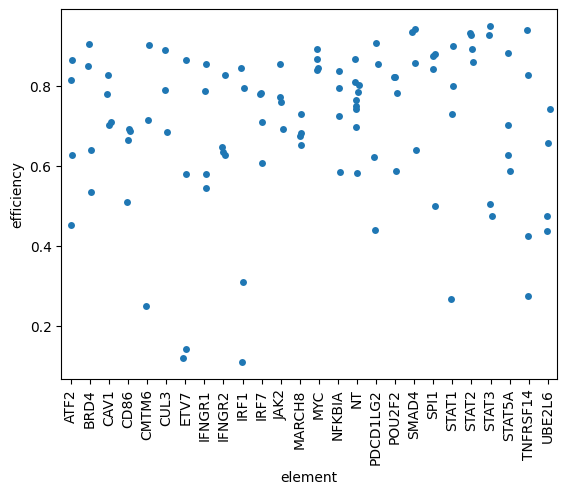

In [28]:
sns.stripplot(median_efficiency, x="element", y="efficiency")
plt.xticks(rotation=90)

In [29]:
effects_df_long = model.get_element_effects()
effects_df_long

,loc,scale,element,gene,z_value,q_value
19,-1.467078,0.063546,STAT1,STAT1,-23.086994,6.255582e-118
8,-0.870581,0.038043,IFNGR2,IFNGR2,-22.884233,6.670168e-116
24,-0.689036,0.055330,UBE2L6,UBE2L6,-12.453305,1.341716e-35
14,-0.862544,0.069675,NFKBIA,NFKBIA,-12.379483,3.375094e-35
4,-0.726585,0.059581,CMTM6,CMTM6,-12.194814,3.312600e-34
23,-0.761810,0.076970,TNFRSF14,TNFRSF14,-9.897463,4.269694e-23
6,-0.756493,0.078460,ETV7,ETV7,-9.641793,5.324942e-22
21,-0.530750,0.062806,STAT3,STAT3,-8.450695,2.895739e-17
7,-0.250006,0.036490,IFNGR1,IFNGR1,-6.851430,7.311510e-12
11,-0.479147,0.072443,JAK2,JAK2,-6.614112,3.737877e-11


In [30]:
effects_df = effects_df_long.pivot_table(values="loc", index="element", columns="gene")
effects_df

gene,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
element,,,,,,,,,,,,,,,,,,,,,
ATF2,-0.247277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BRD4,NaN,-0.635468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAV1,NaN,NaN,-1.02939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD86,NaN,NaN,NaN,-0.21308,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CMTM6,NaN,NaN,NaN,NaN,-0.726585,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CUL3,NaN,NaN,NaN,NaN,NaN,-0.580562,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ETV7,NaN,NaN,NaN,NaN,NaN,NaN,-0.756493,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IFNGR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.250006,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IFNGR2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.870581,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
cis_effects = effects_df_long.query("element==gene")
cis_effects

,loc,scale,element,gene,z_value,q_value
19,-1.467078,0.063546,STAT1,STAT1,-23.086994,6.255582e-118
8,-0.870581,0.038043,IFNGR2,IFNGR2,-22.884233,6.670168e-116
24,-0.689036,0.055330,UBE2L6,UBE2L6,-12.453305,1.341716e-35
14,-0.862544,0.069675,NFKBIA,NFKBIA,-12.379483,3.375094e-35
4,-0.726585,0.059581,CMTM6,CMTM6,-12.194814,3.312600e-34
23,-0.761810,0.076970,TNFRSF14,TNFRSF14,-9.897463,4.269694e-23
6,-0.756493,0.078460,ETV7,ETV7,-9.641793,5.324942e-22
21,-0.530750,0.062806,STAT3,STAT3,-8.450695,2.895739e-17
7,-0.250006,0.036490,IFNGR1,IFNGR1,-6.851430,7.311510e-12
11,-0.479147,0.072443,JAK2,JAK2,-6.614112,3.737877e-11


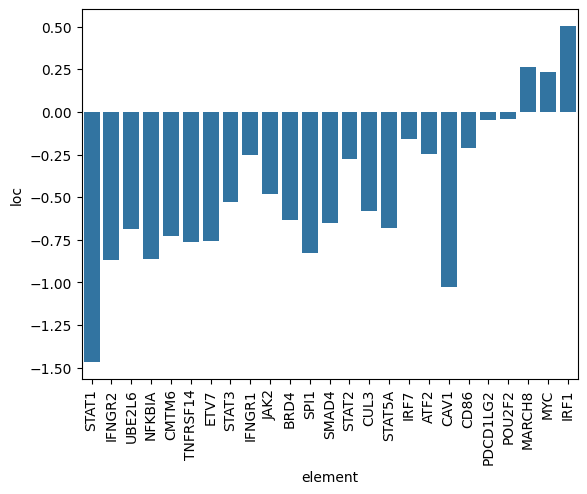

In [32]:
# median_cis_effect = guide.median()["cis_effect"].detach().cpu()
# low_cis_effect, high_cis_effect = (
    # guide.quantiles([0.159, 0.841])["cis_effect"].detach().cpu()
# )
# sigma_cis_effect = high_cis_effect - median_cis_effect
# z_score_cis_effect = median_cis_effect / sigma_cis_effect

sns.barplot(cis_effects, x="element", y="loc")
plt.xticks(rotation=90)
plt.show()

# sns.barplot(x=elements, y=z_score_cis_effect.squeeze())

# plt.xticks(rotation=90)
# plt.show()

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6,control
0,0.041881,0.073549,0.029918,0.063529,0.037421,0.208684,0.064901,-0.145265,-0.068829,-0.222352,...,0.001219,0.009285,0.040927,1.891569,0.926601,0.035544,-0.015827,0.024636,0.034854,0.022159
1,-0.020850,0.010051,0.013456,0.003089,-0.027216,-0.048642,0.037753,-0.083259,-0.074479,-0.057312,...,0.007897,0.002179,0.044257,-0.046283,0.036367,-0.049562,-0.022715,0.103978,-0.064268,0.021934
2,-0.039161,0.029803,0.032621,0.073444,-0.064854,-0.635382,-0.001628,0.097460,-0.034109,-0.057143,...,-0.025661,0.001073,0.126740,-0.036693,0.004836,0.007331,0.006056,-0.070445,0.042239,0.098047
3,-0.063207,-0.104799,-0.067580,-0.065547,-0.040325,0.027071,-0.084991,1.549522,1.582791,0.549490,...,-0.063052,-0.116739,-0.068310,2.059741,-0.018225,-0.049531,-0.052900,-0.057260,-0.066945,-0.062387
4,0.074686,0.009354,0.036355,0.067308,0.104224,0.041585,-0.000068,0.022340,0.086506,-1.346482,...,0.076161,-0.046112,-0.011483,-0.012620,-0.045049,0.008743,0.036846,-0.019662,-0.032254,0.016268
5,0.005359,-0.004014,-0.056991,0.046758,0.006087,0.049219,0.019854,0.085868,0.035354,0.014057,...,0.114027,0.023843,-0.118602,-0.614170,0.244963,-0.001814,-0.055374,0.025602,-0.032872,-0.003629
6,-0.010566,0.029106,-0.016074,0.001967,0.030518,0.021794,-0.023811,0.018599,0.015816,-0.008492,...,0.052061,-0.051018,-0.041861,-0.097263,0.028902,0.004133,0.015735,-0.038630,-0.002950,0.036228
7,0.001077,1.217654,0.037145,0.071969,0.029101,0.046168,-0.009619,0.007611,0.001190,-0.001914,...,-0.002098,0.075455,0.067565,0.041323,0.024744,-0.041305,0.000307,-0.001852,-0.141927,-0.022134
8,0.007918,0.012157,-0.038662,0.000938,-0.011635,-0.046287,0.017485,0.032186,-0.010888,-0.012717,...,-0.043020,-0.052019,0.019833,0.015827,-0.064292,-0.016996,0.084076,-0.101617,0.085647,-0.038160
9,0.045340,-0.035594,-0.062280,0.034555,0.018625,-0.111281,-0.040085,0.009808,0.114034,0.041620,...,-0.035622,0.904079,0.000989,0.022126,0.020889,-0.067099,-0.031600,-0.043684,-0.094079,-0.008535


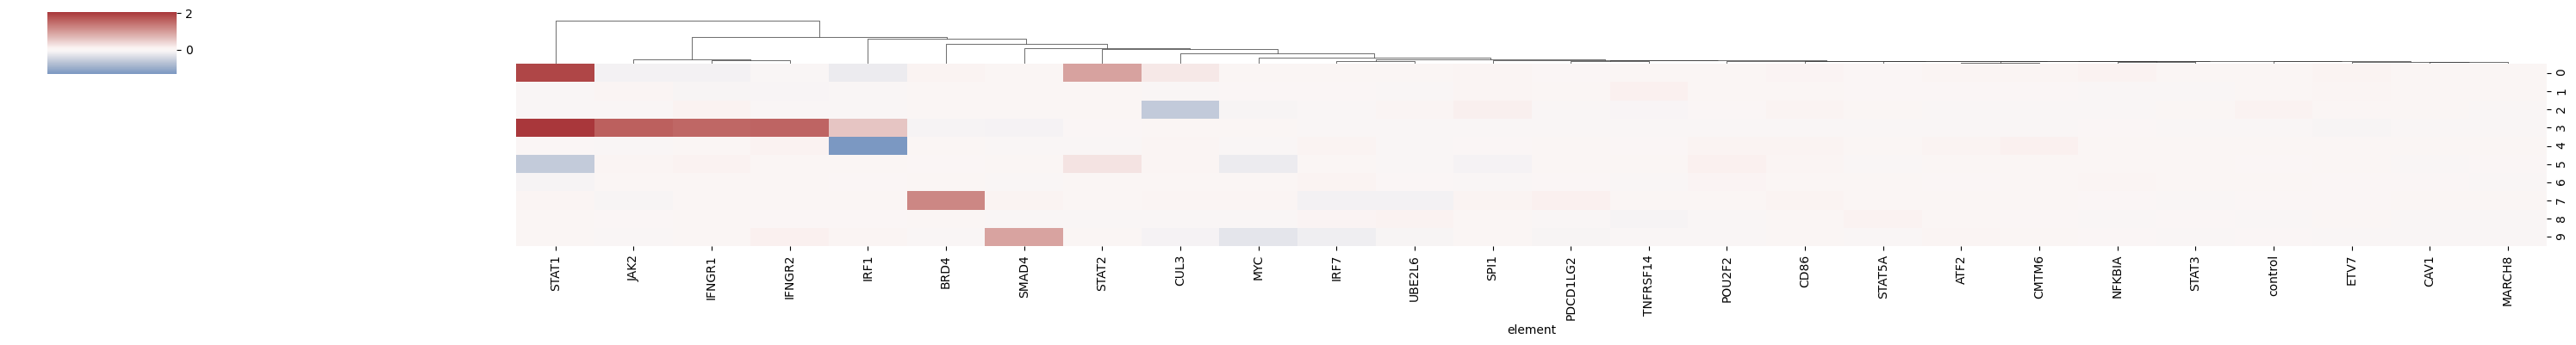

In [33]:
pert_factors = pd.DataFrame(
    model.module.guide.median()["pert_factors"].squeeze(),
    columns=elements,
)
sns.clustermap(pert_factors, cmap="vlag", figsize=(30, 4), row_cluster=False, center=0)
pert_factors



In [34]:
pert_loadings = pd.DataFrame(
    model.module.guide.median()["pert_loadings"].squeeze(),
    columns=mdata["rna"].var_names,
)

pert_loadings


gene_symbol,STAT2,CAV1,STAT1,CD86,IRF7,ATF2,STAT3,JAK2,NFKBIA,SMAD4,...,RP11-54O7.18,C1orf159,TNFRSF18,TNFRSF4,SDF4,B3GALT6,FAM132A,RP5-902P8.12,UBE2J2,SCNN1D
0,-0.436296,-0.001910,-0.046667,-0.058376,-0.651933,-0.019969,0.030755,0.007595,0.029957,-0.048656,...,0.095326,-0.010028,-0.001516,-0.001373,-0.014287,-0.043316,0.011038,-0.040333,-0.008346,0.064698
1,0.033990,-0.020891,0.017612,0.010965,0.024896,0.041459,0.004862,0.040943,0.002813,0.008980,...,0.000808,-0.015082,0.007846,0.004623,-0.021306,-0.025818,-0.003706,-0.027524,-0.013241,-0.003594
2,0.162172,-0.455691,0.047036,0.025041,0.014868,-0.009249,0.014233,0.112401,-0.076035,0.090288,...,0.005963,-0.037164,-0.042155,0.025205,0.181663,-0.035138,0.002543,-0.048451,0.121765,-0.009056
3,-0.443900,-0.191953,-0.639347,0.087255,-0.496361,0.099322,-0.232258,-1.032741,0.280704,0.044019,...,0.137811,-0.112458,0.015436,0.209714,0.069747,0.112297,0.093657,-0.015882,0.105043,0.008430
4,-0.086755,0.156343,-0.312912,-0.456837,-0.081188,-0.024531,-0.170041,0.565035,0.115812,-0.055624,...,-0.024657,0.117920,-0.067583,-0.206696,-0.000863,0.010119,0.111491,0.013393,0.064715,-0.000437
5,-0.010053,0.013576,-0.036972,0.038046,0.155734,0.035867,-0.128759,-0.017676,0.082867,0.071579,...,-0.057763,0.000816,-0.009698,0.019636,-0.026003,-0.013438,0.041614,-0.025864,0.042413,0.014710
6,0.011001,-0.002516,-0.009490,0.021165,0.014211,-0.025493,-0.033905,-0.006346,-0.019289,0.058749,...,-0.031981,0.027601,-0.029961,-0.013869,0.003621,0.010405,0.058712,-0.004642,0.029142,-0.007790
7,-0.035042,-0.024680,0.061078,-0.518851,-0.264985,-0.052938,0.007111,0.040402,0.505140,0.105547,...,-0.010298,-0.053742,-0.043741,-0.022848,0.018245,-0.054977,-0.005425,0.008410,-0.119622,-0.003409
8,0.067842,-0.059111,0.018688,-0.001271,0.026099,-0.000013,-0.023003,-0.021838,-0.013980,-0.007789,...,0.012026,-0.010605,0.003503,-0.005006,0.071317,0.085951,0.052917,0.025524,-0.040064,0.001519
9,-0.091859,0.019730,0.118950,-0.041155,0.059141,0.092211,0.064223,-0.006316,0.197993,-0.030478,...,0.087943,0.027548,-0.022076,0.894341,0.080760,0.189455,-0.092065,0.004120,0.088970,0.011808


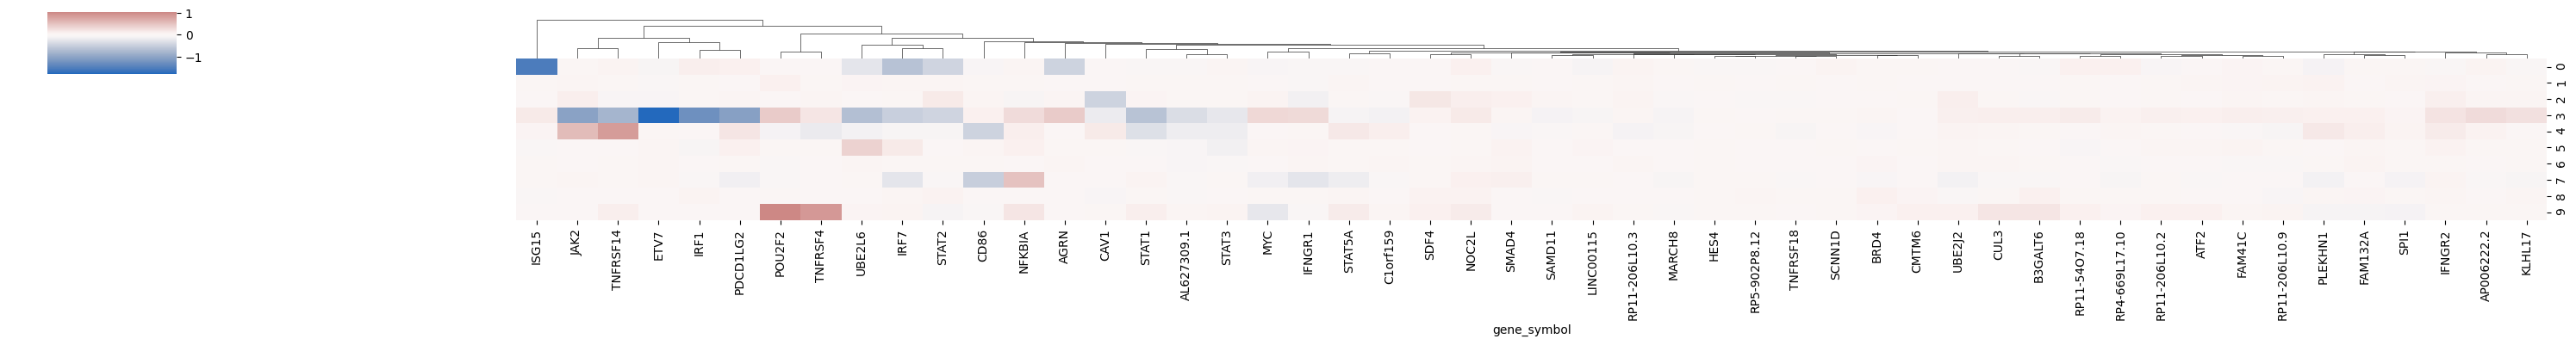

In [35]:
top_genes = (pert_loadings**2).max().nlargest(100).index
pert_loadings_subset = pert_loadings.loc[:, top_genes]
sns.clustermap(pert_loadings_subset, cmap="vlag", row_cluster=False, figsize=(30, 4), center=0)


In [36]:
# effects_df = effects
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

# median_effect = guide.median()["trans_effect"].detach().cpu()
# low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"].detach().cpu()
# sigma_effect = high_effect - low_effect
# z_score_effect = median_effect / sigma_effect

# effects_df = pd.DataFrame(
#     effects,
#     # z_score_effect,
#     columns=adata_subset.var_names,
#     index=elements,
# )
# effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df

In [37]:

plot_genes = [g for g in list(cis_effects["element"]) if g != "control"]
plot_genes

['STAT1',
 'IFNGR2',
 'UBE2L6',
 'NFKBIA',
 'CMTM6',
 'TNFRSF14',
 'ETV7',
 'STAT3',
 'IFNGR1',
 'JAK2',
 'BRD4',
 'SPI1',
 'SMAD4',
 'STAT2',
 'CUL3',
 'STAT5A',
 'IRF7',
 'ATF2',
 'CAV1',
 'CD86',
 'PDCD1LG2',
 'POU2F2',
 'MARCH8',
 'MYC',
 'IRF1']

In [38]:
# effect_variance = effects_df.var(axis=0)
effect_variance = effects_df_long.groupby("gene")["loc"].var()
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
# effect_variance = (effects_df.loc[["STAT3", "STAT5A", "CAV1", "CD86"]].abs()).sum(
#     axis=0
# )
hvgs = effect_variance.nlargest(50).index.tolist()
hvgs
# effects_df[effects_df["gene"].isin(hvgs)]


['ATF2',
 'BRD4',
 'CAV1',
 'CD86',
 'CMTM6',
 'CUL3',
 'ETV7',
 'IFNGR1',
 'IFNGR2',
 'IRF1',
 'IRF7',
 'JAK2',
 'MARCH8',
 'MYC',
 'NFKBIA',
 'PDCD1LG2',
 'POU2F2',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT2',
 'STAT3',
 'STAT5A',
 'TNFRSF14',
 'UBE2L6']

In [39]:
# plt.scatter(guide.median()["gene_mean"].cpu().log(), guide.median()["dispersion"].cpu().log(), alpha=0.1)

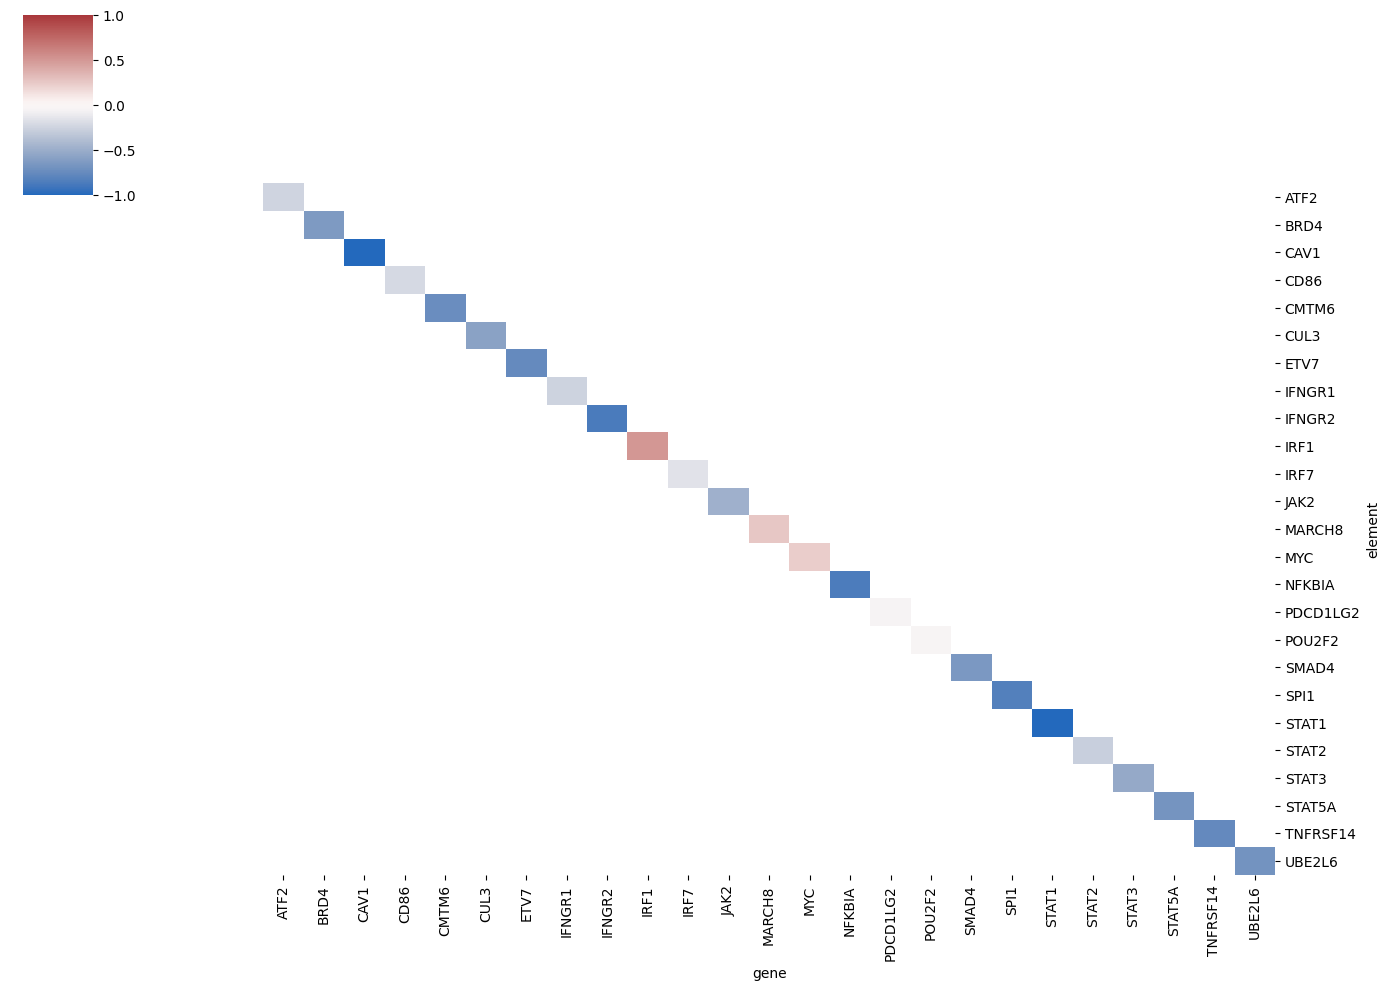

In [40]:
sns.clustermap(
    effects_df,
    vmax=1,
    vmin=-1,
    cmap="vlag",
    metric="cosine",
    figsize=(14, 10),
    col_cluster=False,
    row_cluster=False
)

ValueError: The condensed distance matrix must contain only finite values.

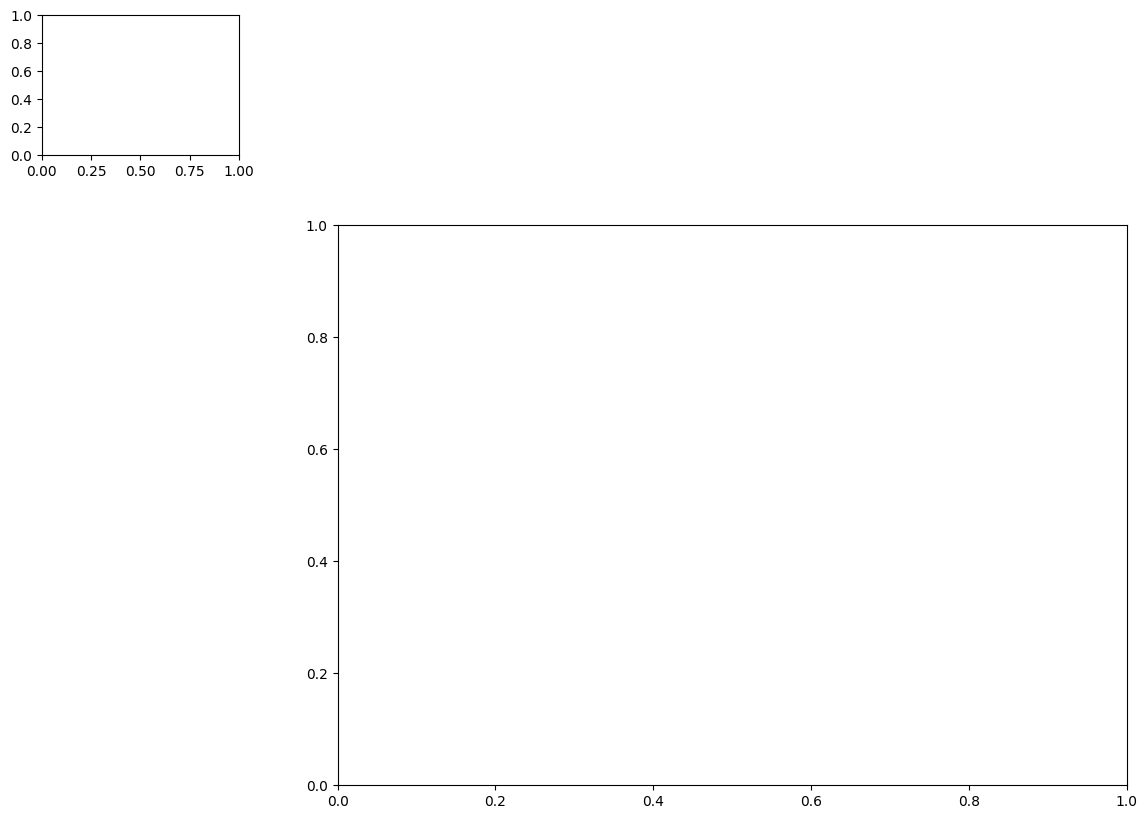

In [41]:
sns.clustermap(
    effects_df[hvgs], vmax=1, vmin=-1, cmap="vlag", metric="cosine", figsize=(14, 10)
)

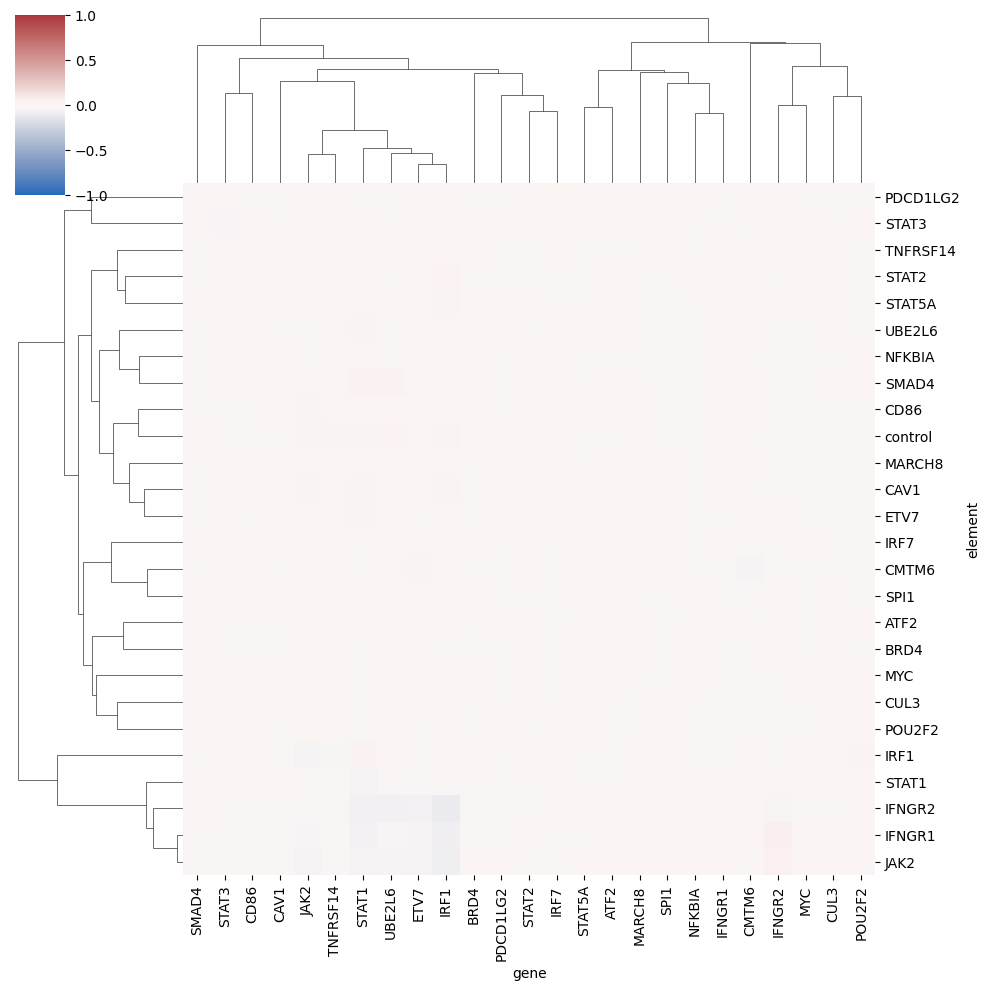

In [38]:
sns.clustermap(
    effects_df[[g for g in plot_genes if g in effects_df.columns]], vmax=1, vmin=-1, cmap="vlag", metric="cosine", figsize=(10, 10)
)

In [39]:
if not smoke_test:
    pyro.get_param_store().save("params.save")

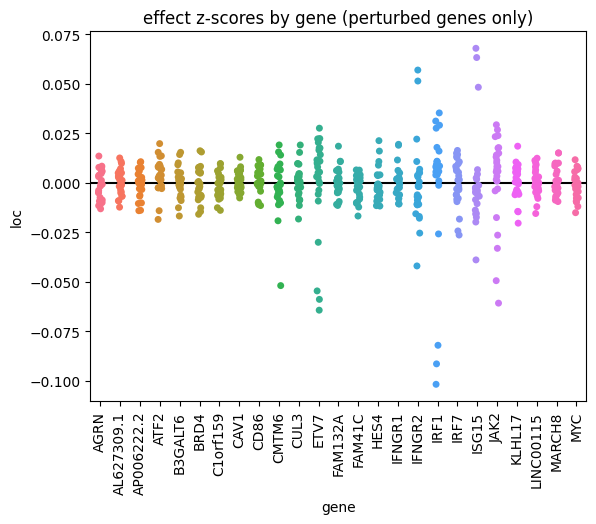

In [40]:
n_plot_genes = 25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
#
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("loc")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

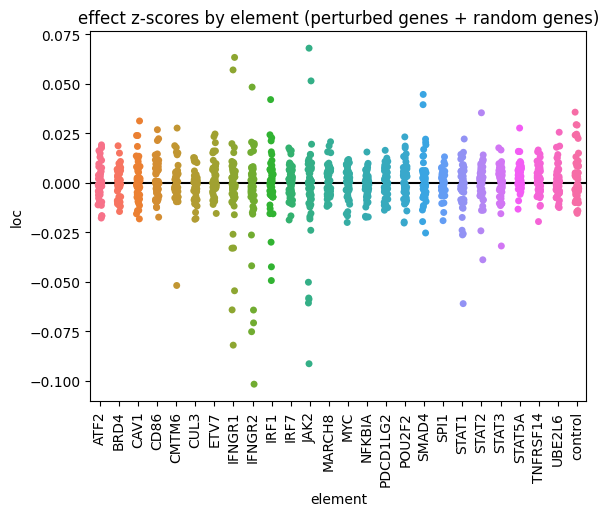

In [41]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("loc")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

In [42]:
effects_df.T["CMTM6"].sort_values()

gene
CMTM6           -0.051952
STAT1           -0.009631
POU2F2          -0.009586
UBE2J2          -0.008582
RP4-669L17.10   -0.008312
B3GALT6         -0.007706
NFKBIA          -0.007233
IFNGR2          -0.007197
IRF7            -0.006104
ISG15           -0.005746
RP11-206L10.2   -0.004456
MYC             -0.004397
SMAD4           -0.004167
PLEKHN1         -0.003253
BRD4            -0.003022
CUL3            -0.002808
IFNGR1          -0.002405
PDCD1LG2        -0.002314
FAM41C          -0.002096
RP11-206L10.3   -0.001896
SCNN1D          -0.001715
HES4            -0.001499
LINC00115       -0.001206
CAV1            -0.001102
SDF4            -0.000910
AGRN            -0.000290
KLHL17           0.000473
SPI1             0.000545
AL627309.1       0.001289
AP006222.2       0.001405
C1orf159         0.001554
STAT2            0.001625
TNFRSF4          0.001647
NOC2L            0.002371
RP11-206L10.9    0.002705
UBE2L6           0.003791
TNFRSF14         0.004142
CD86             0.004251
RP11-54